In [ ]:
# Import Major Liabraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. **Project Title** - Zomato Restaurant Analysis | Clustering + Sentiment Analysis


###**Author:** Poonam Saini  
###**Objective:** Analyze restaurant pricing, ratings, clustering and review sentiment  
###**Techniques Used:** EDA, Hypothesis Testing, KMeans Clustering, Sentiment Analysis (NLP)
###**Tools:** Python, Pandas, Matplotlib, Seaborn, Scikit-learn, NLTK (VADER)


#2. **Problem Statement**

The objective of this project is to analyze Zomato's restaurant and review data to uncover insights related to restaurant pricing, customer ratings, popularity, and sentiment.  
The project aims to help food platforms and restaurant owners make data-driven decisions by understanding customer behavior and restaurant segmentation.


#3. **Dataset Description**

Two datasets are used in this project:

1. **Restaurant Metadata Dataset**
   - Restaurant name
   - Cost per person
   - Cuisine types
   - Timings and collections

2. **Restaurant Reviews Dataset**
   - Restaurant name
   - Customer reviews
   - Ratings
   - Review metadata

These datasets together enable both numerical and textual analysis.


##4. **Data Loading & Inspection**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
restaurant = pd.read_csv('/content/drive/MyDrive/zomato/Zomato Project/Zomato Restaurant names and Metadata.csv')
review = pd.read_csv("/content/drive/MyDrive/zomato/Zomato Project/Zomato Restaurant reviews.csv")

In [ ]:
restaurant.shape,review.shape

((105, 6), (10000, 7))

In [ ]:
restaurant.columns , review.columns

(Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object'),
 Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
        'Pictures'],
       dtype='object'))

In [ ]:
restaurant.head(5)

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [ ]:
review.head(5)

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


In [ ]:
review['Reviewer'].nunique()

7446

In [ ]:
restaurant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB


In [ ]:
review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


#4. **Data Cleaning & Preprocessing**

In this phase, the datasets were cleaned and prepared for analysis.  
Key preprocessing steps included:

- Handling missing values
- Converting ratings from text to numeric format
- Removing irrelevant features & values such as "Like"
- Standardizing cost values
- Creating clean, analysis-ready DataFrames

This ensured consistency and reliability for further analysis.

**4(a)  Restaurant Dataset**

In [ ]:
# Drop irrelevant columns
rest_clean = restaurant.drop(columns = ["Links","Timings"])

In [ ]:
# Handling null values
rest_clean["Collections"] = rest_clean["Collections"].fillna("Not Specified")

In [ ]:
rest_clean.isnull().sum()

,0
Name,0
Cost,0
Collections,0
Cuisines,0


In [ ]:
# Data types
rest_clean['Cost'] = rest_clean['Cost'].str.replace(',', '')
rest_clean['Cost'] = rest_clean['Cost'].astype(float)

**4(b) Review dataset**

In [ ]:
# Drop irrelevant columns
reviews_clean = review.drop(
    columns=['Reviewer', 'Metadata', 'Time', 'Pictures']
)

In [ ]:
# Handling null values
reviews_clean.isnull().sum()

,0
Restaurant,0
Review,45
Rating,38


In [ ]:
reviews_clean = reviews_clean.dropna(
    subset=['Rating','Review']
    )

In [ ]:
# Filter Ratings
reviews_clean['Rating'].value_counts()

,count
Rating,
5,3826
4,2373
1,1735
3,1192
2,684
4.5,69
3.5,47
2.5,19
1.5,9


In [ ]:
reviews_clean = reviews_clean[reviews_clean['Rating'] != 'Like']

In [ ]:
reviews_clean['Rating'] = reviews_clean['Rating'].astype(float)

#5. **Exploratory Data Analysis (EDA)**

Exploratory Data Analysis was performed to understand the distribution and patterns in the data.

Key analyses included:
- Distribution of restaurant costs
- Cuisine popularity
- Rating distribution
- Top restaurants by rating


**5(a) Restaurant-Level**

(i) Distribution of Restaurant cost

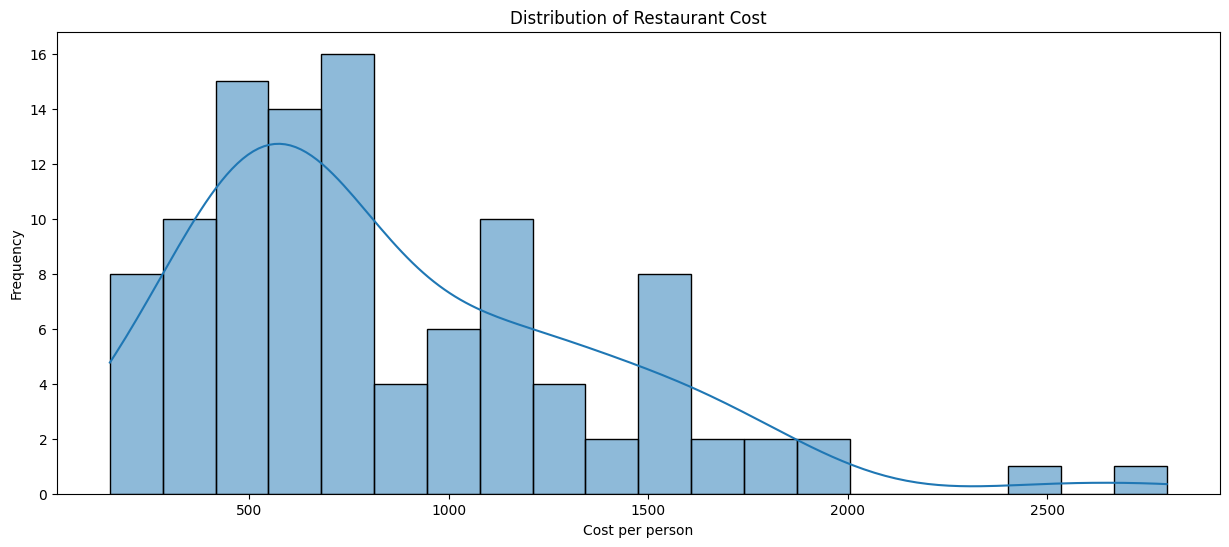

In [ ]:


plt.figure(figsize=(15, 6))
sns.histplot(rest_clean['Cost'], bins=20 ,kde=True)
plt.title('Distribution of Restaurant Cost')
plt.xlabel('Cost per person')
plt.ylabel('Frequency')
plt.show()

Insight: The majority of restaurants are concentrated in the low to mid-cost range, indicating that Zomato’s platform primarily serves budget-friendly customers. Premium restaurants exist but form a smaller segment.

(ii) Top 10 Most Common Cuisine

In [ ]:
cuisine_series = rest_clean['Cuisines'].str.split(",").explode().str.strip()

In [ ]:
Top_cuisine = cuisine_series.value_counts().head(10)

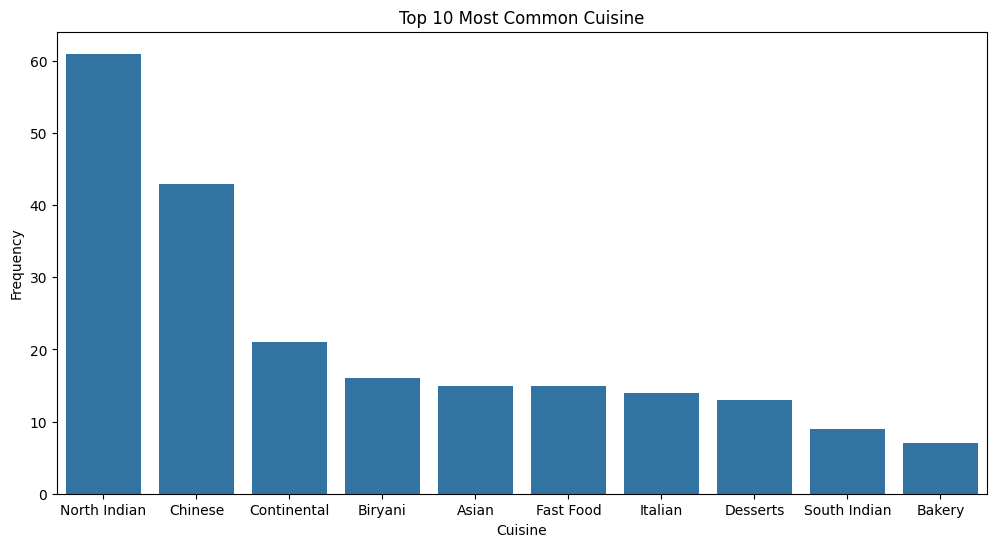

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=Top_cuisine.index,y=Top_cuisine.values)
plt.title('Top 10 Most Common Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Frequency')
plt.show()

Insight:
North Indian cuisine is the most dominant category, followed by Chinese cuisine. This indicates a strong customer preference for these cuisines, while South Indian and Bakery cuisines are comparatively less represented.However location of the restaurant could also be a reason for it.

**5(a) Reviews-Level**

(i) Distribution of Customer Ratings

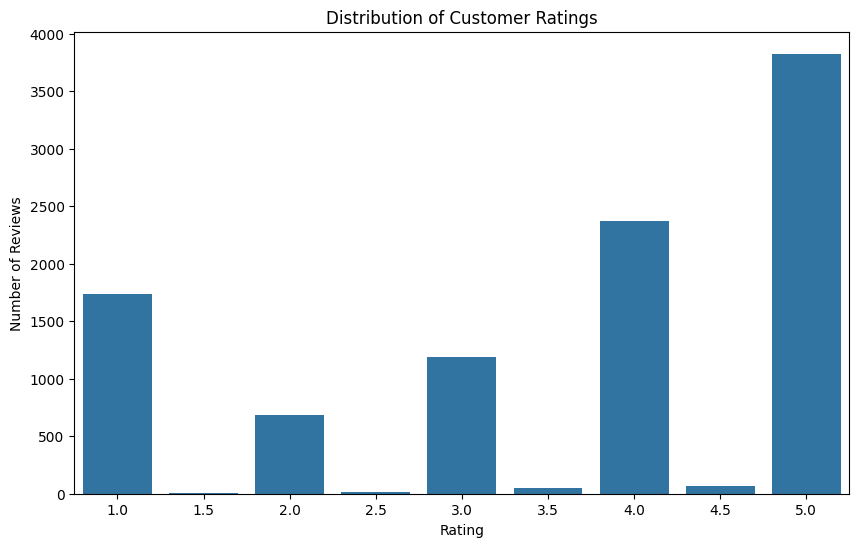

In [ ]:
reviews_clean = review.drop(
    columns=['Reviewer', 'Metadata', 'Time', 'Pictures']
)

reviews_clean = reviews_clean.dropna(
    subset=['Rating','Review']
    )

reviews_clean = reviews_clean[reviews_clean['Rating'] != 'Like']

reviews_clean['Rating'] = reviews_clean['Rating'].astype(float)

plt.figure(figsize=(10,6))
sns.countplot(x=reviews_clean['Rating'])
plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

Insight:
The distribution of customer ratings is skewed towards higher ratings, with 5-star and 4-star reviews forming the majority. However, a noticeable number of 1-star reviews indicate the presence of dissatisfied customers.

5(ii) Top Reviewed Restaurants

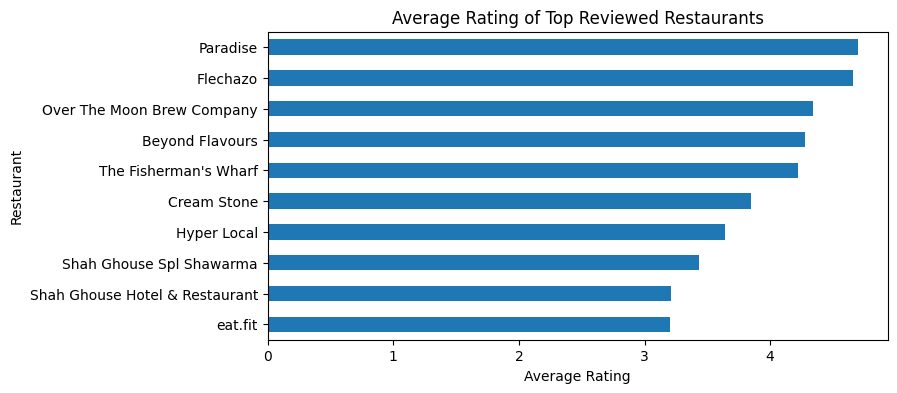

In [ ]:
avg_rating = reviews_clean.groupby('Restaurant')['Rating'].mean()
top_restaurants = reviews_clean['Restaurant'].value_counts().head(10).index

avg_rating.loc[top_restaurants].sort_values().plot(kind='barh', figsize=(8,4))
plt.title("Average Rating of Top Reviewed Restaurants")
plt.xlabel("Average Rating")
plt.show()


**## Key Insights**
- Most restaurants fall into a mid-price range.
- North Indian cuisine is the most dominant.
- Ratings are spread across all cost levels, indicating price alone does not determine satisfaction.

#6. **Hypothesis Testing**

**Hypothesis 1: Does restaurant cost influence customer ratings?**

**Null Hypothesis (H₀):** Restaurant cost has no influence on customer ratings  
**Alternative Hypothesis (H₁):** Restaurant cost influences customer ratings


In [ ]:
merged_df = pd.merge(
    rest_clean, reviews_clean,
    left_on='Name', right_on='Restaurant',
    how='inner'
)

In [ ]:
merged_df[['Cost','Rating']].corr()

,Cost,Rating
Cost,1.000000,0.144119
Rating,0.144119,1.000000


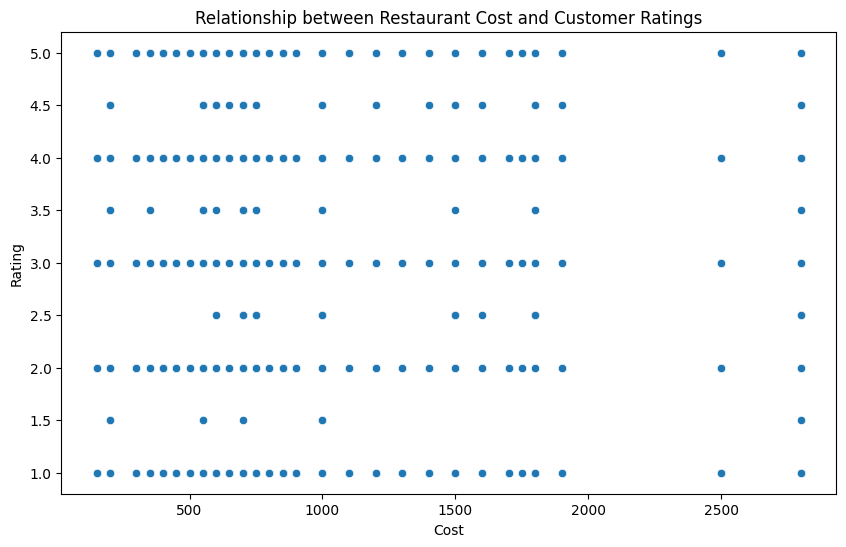

In [ ]:
# Scatter Plot

plt.figure(figsize=(10,6))
sns.scatterplot(data=merged_df,x='Cost',y='Rating')
plt.title("Relationship between Restaurant Cost and Customer Ratings")
plt.xlabel("Cost")
plt.ylabel("Rating")
plt.show()

**Result:**  
Scatter plots and correlation analysis showed a weak relationship between cost and rating.

**Conclusion:**  
Higher restaurant cost does not guarantee higher customer satisfaction.  
The null hypothesis is supported.


**Hypothesis 2: Do restaurants with more reviews have higher ratings?**

**Null Hypothesis (H₀):** The number of reviews a restaurant has does not significantly affect its average rating.

**Alternative Hypothesis (H₁):** Restaurants with a higher number of reviews tend to have higher average ratings.

In [ ]:
review_summary = reviews_clean.groupby('Restaurant').agg(
    review_count=('Rating', 'count'),
    avg_rating=('Rating', 'mean')
).reset_index()

In [ ]:
review_summary[['review_count','avg_rating']].corr()

,review_count,avg_rating
review_count,1.000000,-0.117705
avg_rating,-0.117705,1.000000


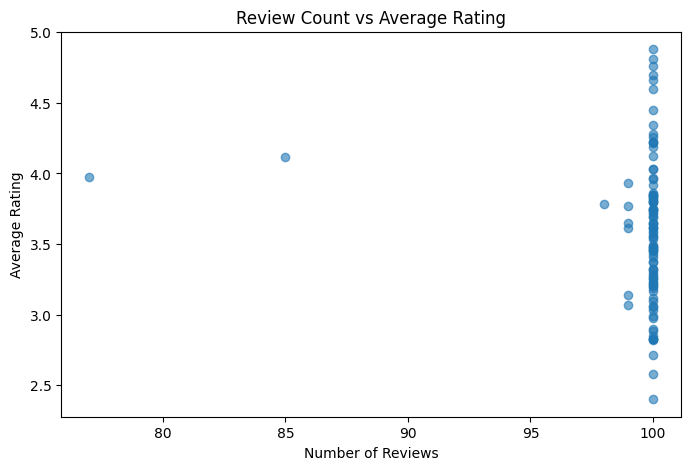

In [ ]:
  plt.figure(figsize=(8,5))
plt.scatter(
    review_summary['review_count'],
    review_summary['avg_rating'],
    alpha=0.6
)
plt.xlabel("Number of Reviews")
plt.ylabel("Average Rating")
plt.title("Review Count vs Average Rating")
plt.show()

**Observation:**  
Review count was nearly uniform (~100) across restaurants.

**Correlation:** –0.117


**Conclusion:**  
This hypothesis was inconclusive due to limited variance in review count, highlighting a dataset limitation rather than a real-world effect.


#7. **Feature Engineering**

For modeling, relevant numerical features were selected:

- Average restaurant rating : Customer satisfaction
- Cost per person : Pricing segmentation
- Review count per restaurant : Popularity proxy

Categorical features and text were excluded from clustering to maintain numerical consistency.


In [ ]:
cluster_df = review_summary.merge(
    rest_clean[['Name','Cost']],
    left_on=  'Restaurant',
    right_on= 'Name',
    how = 'inner'
)

In [ ]:
cluster_data = cluster_df[['Cost','avg_rating','review_count']]
cluster_data.head(5)

,Cost,avg_rating,review_count
0,1900.0,3.80,100
1,450.0,3.48,100
2,1100.0,4.76,100
3,1500.0,4.88,100
4,750.0,3.62,100


#8. **Model Building – KMeans Clustering**

Since no target variable was present, an unsupervised learning approach was chosen.

KMeans clustering was applied to segment restaurants based on:
- Cost
- Average rating
- Review count

Features were scaled using StandardScaler to ensure fair distance calculations.


**8(a) Feature Scaling**

Features are scaled using StandardScaler to ensure fair distance calculations.


In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

Choosing Optimal K

The Elbow Method is used to determine the optimal number of clusters.


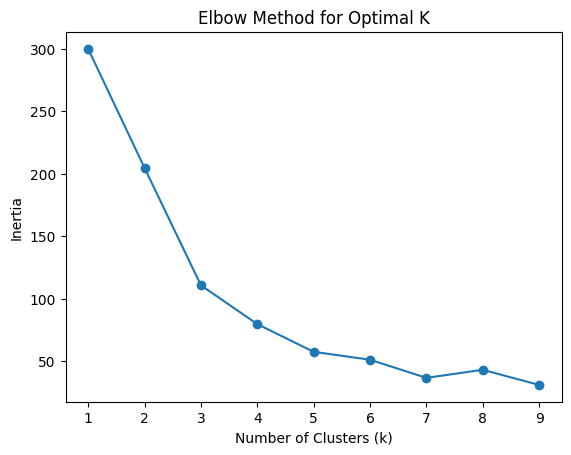

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


Note : k is where inertia starts decreasing slowly
Thus k = 3 for this dataset

In [ ]:
#Apply KMeans Model
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df['Cluster'] = kmeans.fit_predict(scaled_data)


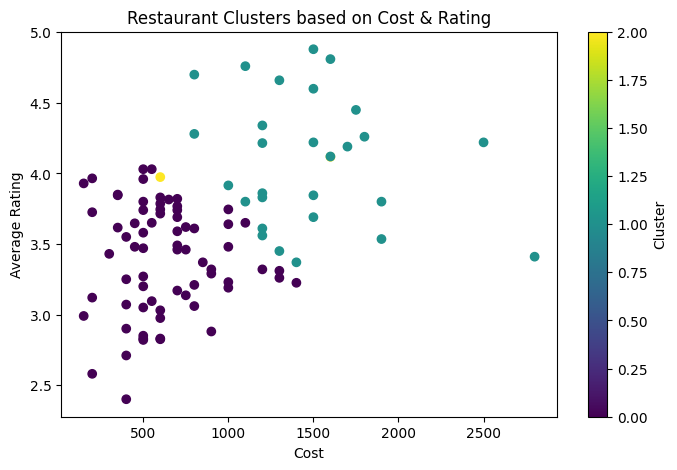

In [ ]:
# Visualize using Scatter plot
plt.figure(figsize=(8,5))
plt.scatter(
    cluster_df['Cost'],
    cluster_df['avg_rating'],
    c=cluster_df['Cluster'],
    cmap='viridis'
)
plt.xlabel("Cost")
plt.ylabel("Average Rating")
plt.title("Restaurant Clusters based on Cost & Rating")
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
cluster_df.groupby('Cluster')[['Cost','avg_rating','review_count']].mean()

,Cost,avg_rating,review_count
Cluster,,,
0,627.857143,3.395963,99.885714
1,1466.071429,4.085000,100.000000
2,1100.000000,4.045837,81.000000


**Cluster Interpretation**

The clustering resulted in three meaningful restaurant segments:

| Cluster | Avg Cost | Avg Rating | Avg Reviews | Interpretation              |
| ------- | -------- | ---------- | ----------- | --------------------------- |
| 0       | Low      | Moderate   | High        | Budget / average performers |
| 1       | High     | High       | High        | Premium restaurants         |
| 2       | Mid      | High       | Moderate    | Value-for-money             |



##Business Implications

Zomato can promote Cluster 2 restaurants as “high-value alternatives” to premium dining

Cluster 1 restaurants can be highlighted for luxury experiences

Cluster 0 restaurants can focus on improving service quality to increase ratings

#9. **Sentiment Analysis**

Sentiment analysis is performed on customer reviews using a rule-based NLP approach (VADER).

The objective is to understand customer emotions and validate alignment between textual sentiment and numerical ratings.


In [ ]:
sentiment_df = reviews_clean[['Restaurant', 'Review', 'Rating']].copy()
sentiment_df.head()

import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
sentiment_df['Sentiment_Score'] = sentiment_df['Review'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

In [ ]:
def sentiment_label(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

sentiment_df['Sentiment'] = sentiment_df['Sentiment_Score'].apply(sentiment_label)


In [ ]:
sentiment_df['Sentiment'].value_counts()

,count
Sentiment,
Positive,7375
Negative,1834
Neutral,745


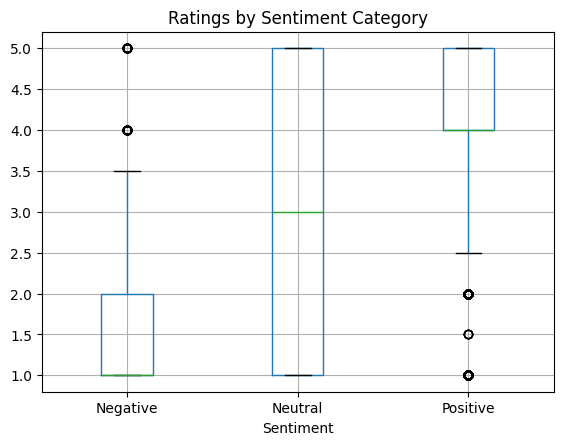

In [ ]:
sentiment_df.boxplot(column='Rating', by='Sentiment')
plt.title("Ratings by Sentiment Category")
plt.suptitle("")
plt.show()


**Results showed:**
- Positive sentiment reviews had higher ratings
- Negative sentiment aligned with lower ratings
- Neutral sentiment showed wide variability

This confirms the reliability of customer feedback on the platform.



#10. **Insights & Business Recommendations**

**Key Insights**

North Indian cuisine dominates the restaurant landscape, indicating strong customer preference and market demand.

Most restaurants fall into the mid-cost range, suggesting affordability is a key factor in customer acquisition.

Higher restaurant cost does not guarantee higher ratings, as customer ratings are distributed across all cost levels.

Hypothesis testing showed no strong relationship between review count and average rating, as review counts were nearly constant.

KMeans clustering revealed three clear restaurant segments:

Budget restaurants with average ratings

Premium restaurants with consistently high ratings

Mid-range restaurants with good customer perception

Sentiment analysis showed that positive sentiment strongly aligns with higher ratings, validating customer feedback quality.


**Business Recommendations**

Restaurants should focus on service quality and consistency, not just pricing, to improve customer ratings.

Budget restaurants can compete effectively by improving customer experience, as high ratings are achievable even at lower costs.

Food delivery platforms can use cluster-based segmentation to:

Promote premium restaurants to high-spending users

Recommend value-for-money restaurants to price-sensitive users

Sentiment analysis can be used for real-time monitoring of customer feedback to detect service issues early.

#11. **Limitations & Future Scope**

### Limitations
- Uniform review counts limited correlation analysis
- KMeans assumes spherical clusters
- Sentiment analysis was rule-based

### Future Scope
- Advanced NLP models (BERT)
- Cuisine-based clustering
- Recommendation system development
- Location and time-based analysis


#13. **Conclusion**

This project demonstrates a complete data science workflow involving data cleaning, EDA, hypothesis testing, clustering, and sentiment analysis.  

The insights derived can help food platforms improve recommendations, pricing strategies, and customer experience using data-driven decision making.


In [ ]:
print("Project Completed Successfully")